# Анализ и прогнозирование выживаемости пассажиров Титаника

**Цель исследования:**  
На основе данных о пассажирах Титаника (train.csv) построить модель машинного обучения, которая предсказывает, выжил ли человек (Survived = 0 или 1). В дальнейшем модель будет применена к тестовым данным (test.csv).

**Описание данных:**  
- PassengerId — уникальный идентификатор пассажира  
- Survived — целевая переменная (0 = погиб, 1 = выжил)  
- Pclass — класс билета (1, 2, 3)  
- Name — имя  
- Sex — пол  
- Age — возраст  
- SibSp — количество братьев/сестер/супругов на борту  
- Parch — количество родителей/детей на борту  
- Ticket — номер билета  
- Fare — стоимость билета  
- Cabin — номер каюты  
- Embarked — порт посадки (C = Cherbourg, Q = Queenstown, S = Southampton)

В процессе работы будут выполнены:
- предварительный анализ и визуализация данных,
- очистка и преобразование признаков,
- обучение нескольких моделей классификации,
- сравнение их качества.

### 1. Подготовка окружения и загрузка данных

Импортируются необходимые библиотеки:
- pandas, numpy — для работы с табличными данными и числовыми расчётами;
- matplotlib, seaborn — для визуализации;
- warnings — для подавления предупреждений.

Объявляются конфигурационные данные

Загружаются тренировочный и тестовый наборы. С помощью `pd.set_option` настраивается отображение всех колонок для удобного просмотра.

In [ ]:
#Importing All Required Libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from warnings import filterwarnings
filterwarnings(action='ignore')

In [416]:
# PARAMETER CONFIGURATION

# Data Splitting Parameters
RANDOM_STATE = 7 # Fix seed for reproducibility of results
TEST_SIZE = 0.3 # Proportion of data for testing (30% is the default value)

# Model Parameters
KNN_N_NEIGHBORS = 5 # Number of neighbors for KNN (default value)
DT_CRITERION = 'entropy' # Split quality criterion for decision trees
# 'entropy' produces more balanced trees compared to 'gini'

# Visualization options
PLOT_FIGURE_SIZE = (10, 6) # Default plot size

In [367]:
#Loading Datasets
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 1000)
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,...,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,...,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,...,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,...,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,...,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,...,0,373450,8.0500,NaN,S


### 2. Первичный анализ данных

#### 2.1 Размеры и структура
- `train.shape` — (891, 12) — 891 запись, 12 признаков.
- `test.shape` — (418, 11) — в тестовом наборе нет столбца `Survived`.

#### 2.2 Проверка пропусков
- В тренировочном наборе пропущены значения в колонках `Age` (177), `Cabin` (687), `Embarked` (2).
- В тестовом — пропуски в `Age` (86) и `Fare` (1).  
(далее будет проверенно более детально)

#### 2.3 Описательная статистика
Метод `describe(include='all')` показывает распределение числовых и категориальных признаков. Видно, что:
- средний возраст пассажиров ~29.7 лет;
- большинство билетов — 3-го класса;
- в данных преобладают мужчины (577 против 314 женщин);
- чаще всего пассажиры садились в порту Southampton.

#### 2.4 Сравнение выживших и погибших
Группировка по `Survived` показывает, что среди выживших выше средний класс билета (ближе к 1), ниже средний возраст, выше стоимость билета.

In [ ]:
#Display shape
train.shape

(891, 12)

In [369]:
test.shape

(418, 11)

In [370]:
train.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [371]:
#Checking for Null values
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [372]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [373]:
#Description of dataset
train.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,...,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,...,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,...,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,...,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,...,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,...,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,...,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,...,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,...,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,...,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,...,0.000000,NaN,31.000000,NaN,NaN


In [374]:
train.groupby('Survived').mean(numeric_only=True)

,PassengerId,Pclass,Age,SibSp,Parch,Fare
Survived,,,,,,
0,447.016393,2.531876,30.626179,0.553734,0.329690,22.117887
1,444.368421,1.950292,28.343690,0.473684,0.464912,48.395408


### 3. Корреляция признаков

Рассчитана корреляционная матрица для числовых переменных. Наибольшие связи с целевой переменной `Survived` имеют:
- `Pclass` (отрицательная корреляция -0.34) — чем выше класс (т.е. меньше номер), тем больше шансов выжить;
- `Fare` (положительная 0.26) — дорогие билеты чаще ассоциируются с выживанием.

Также заметна высокая корреляция между `Pclass` и `Fare` (-0.55) — чем выше класс, тем дороже билет, что логично.

In [ ]:
train.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [376]:
corr_matrix = train.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
corr_series = corr_matrix.where(mask).stack()
corr_series = corr_series[corr_series != 1]
top_corr = corr_series.abs().sort_values(ascending=False).head(5)

print("Top 5 correlations by absolute value:")
top_corr

Top 5 correlations by absolute value:


Pclass    Fare      0.549500
SibSp     Parch     0.414838
Pclass    Age       0.369226
Survived  Pclass    0.338481
Age       SibSp     0.308247
dtype: float64

### 4. Визуальный анализ

#### 4.1 Распределение по полу
Построена столбчатая диаграмма количества мужчин и женщин. Мужчин почти вдвое больше.

#### 4.2 Выживаемость по полу
Среднее значение `Survived` в группировке по полу показывает, что выжило ~74% женщин и только ~19% мужчин. Пол — сильный предиктор.

#### 4.3 Выживаемость по классу билета
Два графика — для выживших и погибших — показывают, что среди выживших преобладают пассажиры 1-го класса, а среди погибших — 3-го класса.

#### 4.4 Возрастное распределение
Гистограммы для выживших и погибших: у выживших заметен пик в возрасте 0–10 лет (дети), у погибших — широкий разброс, много людей 20–40 лет.

#### 4.5 Распределение стоимости билета
У выживших больше пассажиров с высокой стоимостью билета (более 50), у погибших — в основном дешёвые билеты.

#### 4.6 Влияние количества родственников
Группировка по `SibSp` показывает, что пассажиры с 1–2 родственниками выживали чаще, чем одинокие или с большими семьями. Аналогично для `Parch` — семьи с 1–3 детьми/родителями имели лучшие шансы.

#### 4.7 Порт посадки
Средняя выживаемость по портам:
- Cherbourg (C) — 55%
- Queenstown (Q) — 39%
- Southampton (S) — 34%

#### 4.8 Тепловая карта: порт и класс
Большинство пассажиров из порта S ехали в 3-м классе, из порта C — в 1-м классе, что объясняет разницу в выживаемости.

In [ ]:
male_ind = len(train[train['Sex'] == 'male'])
print("No of Males in Titanic:", male_ind)

No of Males in Titanic: 577


In [378]:
female_ind = len(train[train['Sex'] == 'female'])
print("No of Females in Titanic:", female_ind)

No of Females in Titanic: 314


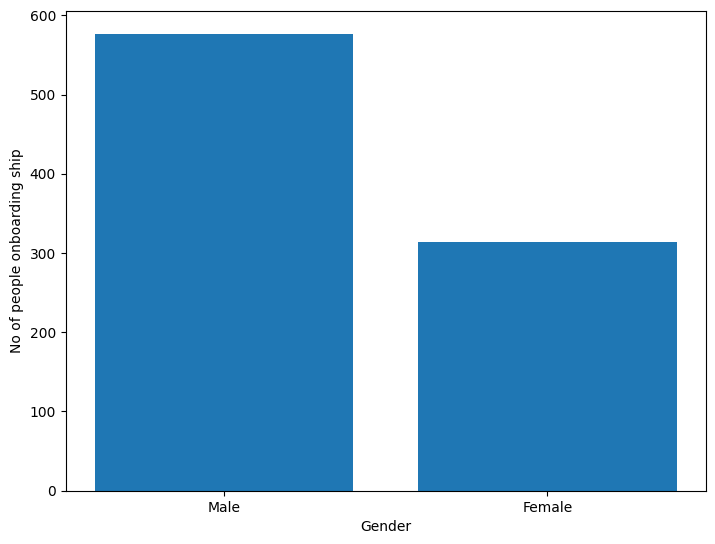

In [379]:
#Plotting
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
gender = ['Male','Female']
index = [577,314]
ax.bar(gender,index)
plt.xlabel("Gender")
plt.ylabel("No of people onboarding ship")
plt.show()

In [380]:
alive = len(train[train['Survived'] == 1])
dead = len(train[train['Survived'] == 0])

In [381]:
train.groupby('Sex')[['Survived']].mean()

,Survived
Sex,
female,0.742038
male,0.188908


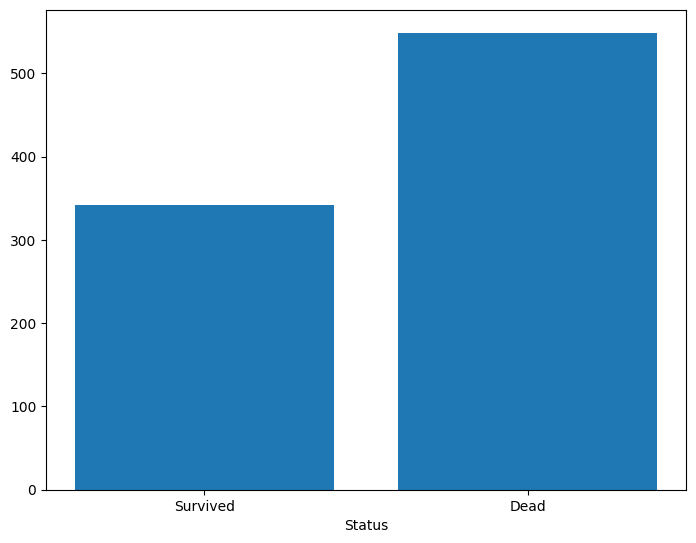

In [382]:
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
status = ['Survived','Dead']
ind = [alive,dead]
ax.bar(status,ind)
plt.xlabel("Status")
plt.show()

Text(0.5, 1.0, "Bar graph of people according to ticket class in which people couldn't survive")

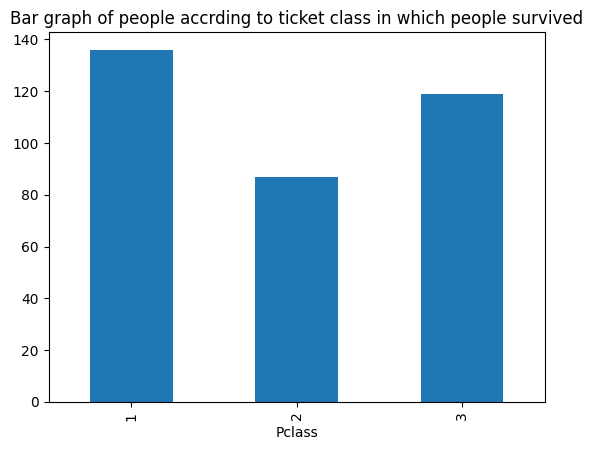

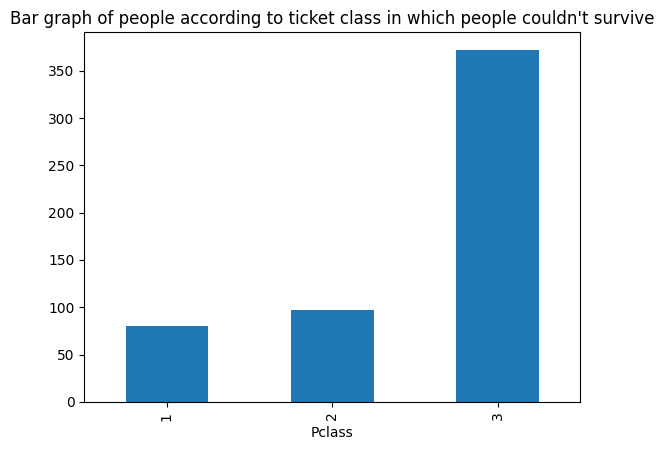

In [383]:
plt.figure(1)
train.loc[train['Survived'] == 1, 'Pclass'].value_counts().sort_index().plot.bar()
plt.title('Bar graph of people accrding to ticket class in which people survived')


plt.figure(2)
train.loc[train['Survived'] == 0, 'Pclass'].value_counts().sort_index().plot.bar()
plt.title('Bar graph of people according to ticket class in which people couldn\'t survive')

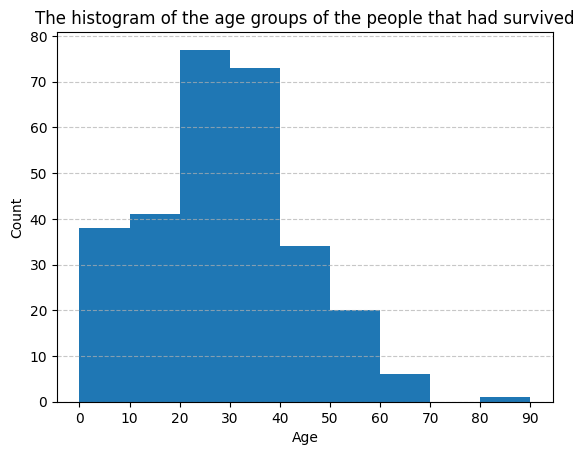

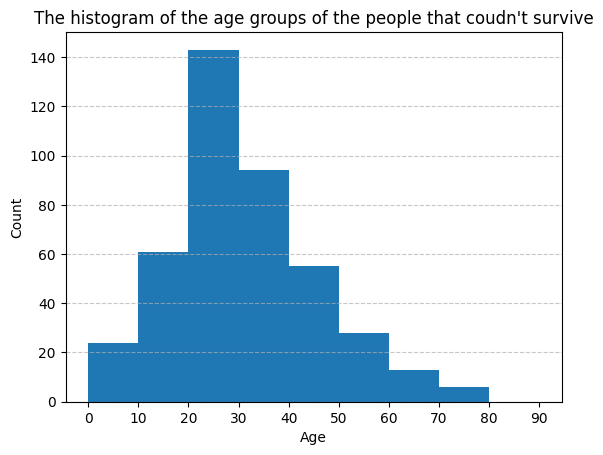

In [384]:
plt.figure(1)
age  = train.loc[train.Survived == 1, 'Age']
plt.title('The histogram of the age groups of the people that had survived')
plt.xlabel('Age')
plt.ylabel('Count')
plt.hist(age, np.arange(0,100,10))
plt.xticks(np.arange(0,100,10))
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.figure(2)
age  = train.loc[train.Survived == 0, 'Age']
plt.title('The histogram of the age groups of the people that coudn\'t survive')
plt.xlabel('Age')
plt.ylabel('Count')
plt.hist(age, np.arange(0,100,10))
plt.xticks(np.arange(0,100,10))
plt.grid(axis='y', linestyle='--', alpha=0.7)

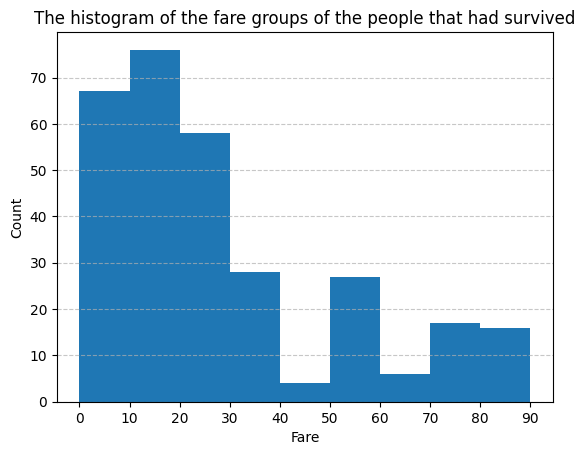

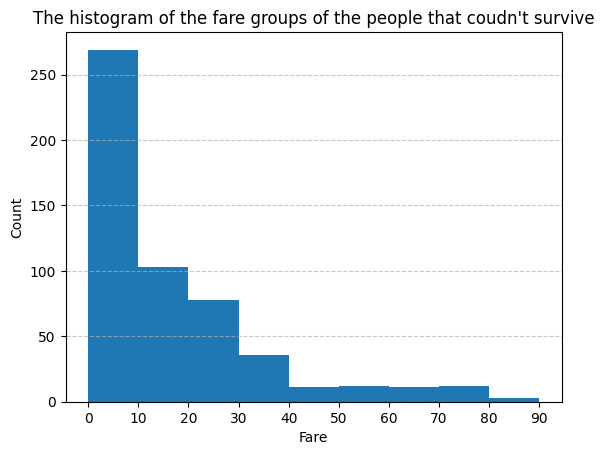

In [385]:
plt.figure(1)
fare = train.loc[train.Survived == 1, 'Fare']
plt.title('The histogram of the fare groups of the people that had survived')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.hist(fare, np.arange(0,100,10))
plt.xticks(np.arange(0,100,10))
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.figure(2)
fare  = train.loc[train.Survived == 0, 'Fare']
plt.title('The histogram of the fare groups of the people that coudn\'t survive')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.hist(fare, np.arange(0,100,10))
plt.xticks(np.arange(0,100,10))
plt.grid(axis='y', linestyle='--', alpha=0.7)

In [386]:
train[["SibSp", "Survived"]].groupby(['SibSp'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,SibSp,Survived
1,1,0.535885
2,2,0.464286
0,0,0.345395
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


In [387]:
train[["Pclass", "Survived"]].groupby(['Pclass'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [388]:
train[["Age", "Survived"]].groupby(['Age'], as_index=False).mean().sort_values(by='Age', ascending=True)

,Age,Survived
0,0.42,1.0
1,0.67,1.0
2,0.75,1.0
3,0.83,1.0
4,0.92,1.0
...,...,...
83,70.00,0.0
84,70.50,0.0
85,71.00,0.0
86,74.00,0.0


In [389]:
train[["Embarked", "Survived"]].groupby(['Embarked'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.336957


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


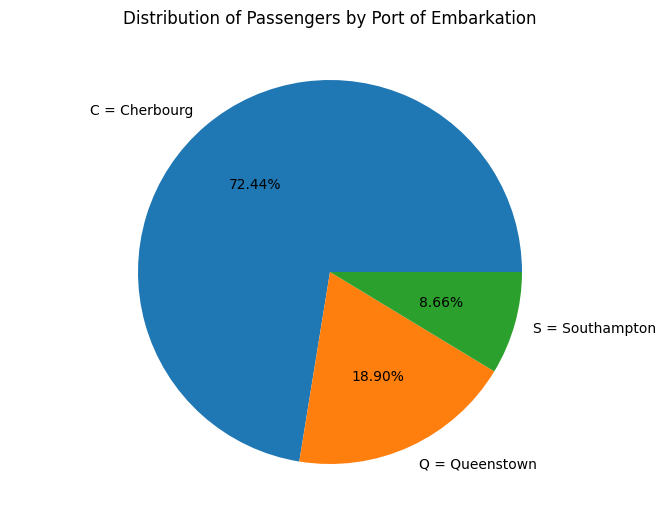

In [390]:
port_counts = train['Embarked'].value_counts(normalize=True)

fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1])
ax.axis('equal')

labels = ['C = Cherbourg', 'Q = Queenstown', 'S = Southampton']
sizes = port_counts

ax.pie(sizes, labels=labels, autopct='%1.2f%%')
plt.title('Distribution of Passengers by Port of Embarkation')
plt.show()

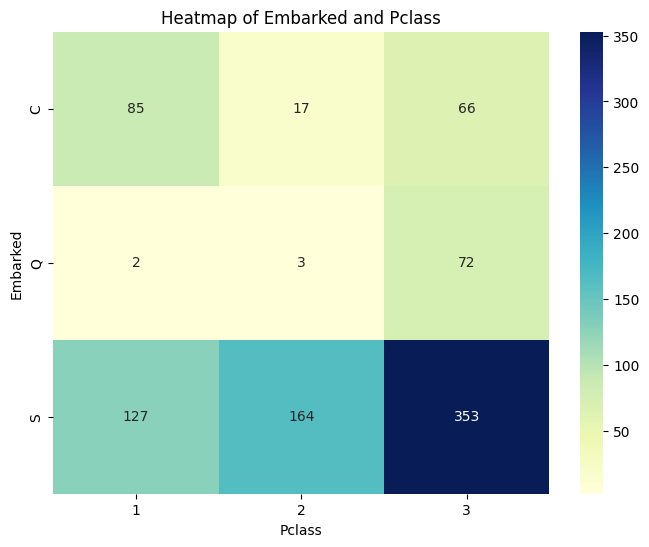

In [391]:
crosstab = pd.crosstab(train['Embarked'], train['Pclass'])

plt.figure(figsize=(8, 6))
sns.heatmap(crosstab, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap of Embarked and Pclass')
plt.xlabel('Pclass')
plt.ylabel('Embarked')
plt.show()

In [392]:
mean_pclass = train.groupby('Embarked')['Pclass'].mean()

print("Mean Pclass by Embarked:")
mean_pclass

Mean Pclass by Embarked:


Embarked
C    1.886905
Q    2.909091
S    2.350932
Name: Pclass, dtype: float64

### 2.2 Детальный анализ пропусков в данных

Прежде чем заполнять пропуски, важно понять их природу. Случайны ли они или связаны с другими характеристиками пассажиров? Это поможет выбрать правильную стратегию обработки.

#### 2.2.1 Визуализация пропусков с помощью матрицы
Построим матрицу пропусков, чтобы увидеть, есть ли закономерности в их распределении.

<Figure size 1200x800 with 0 Axes>

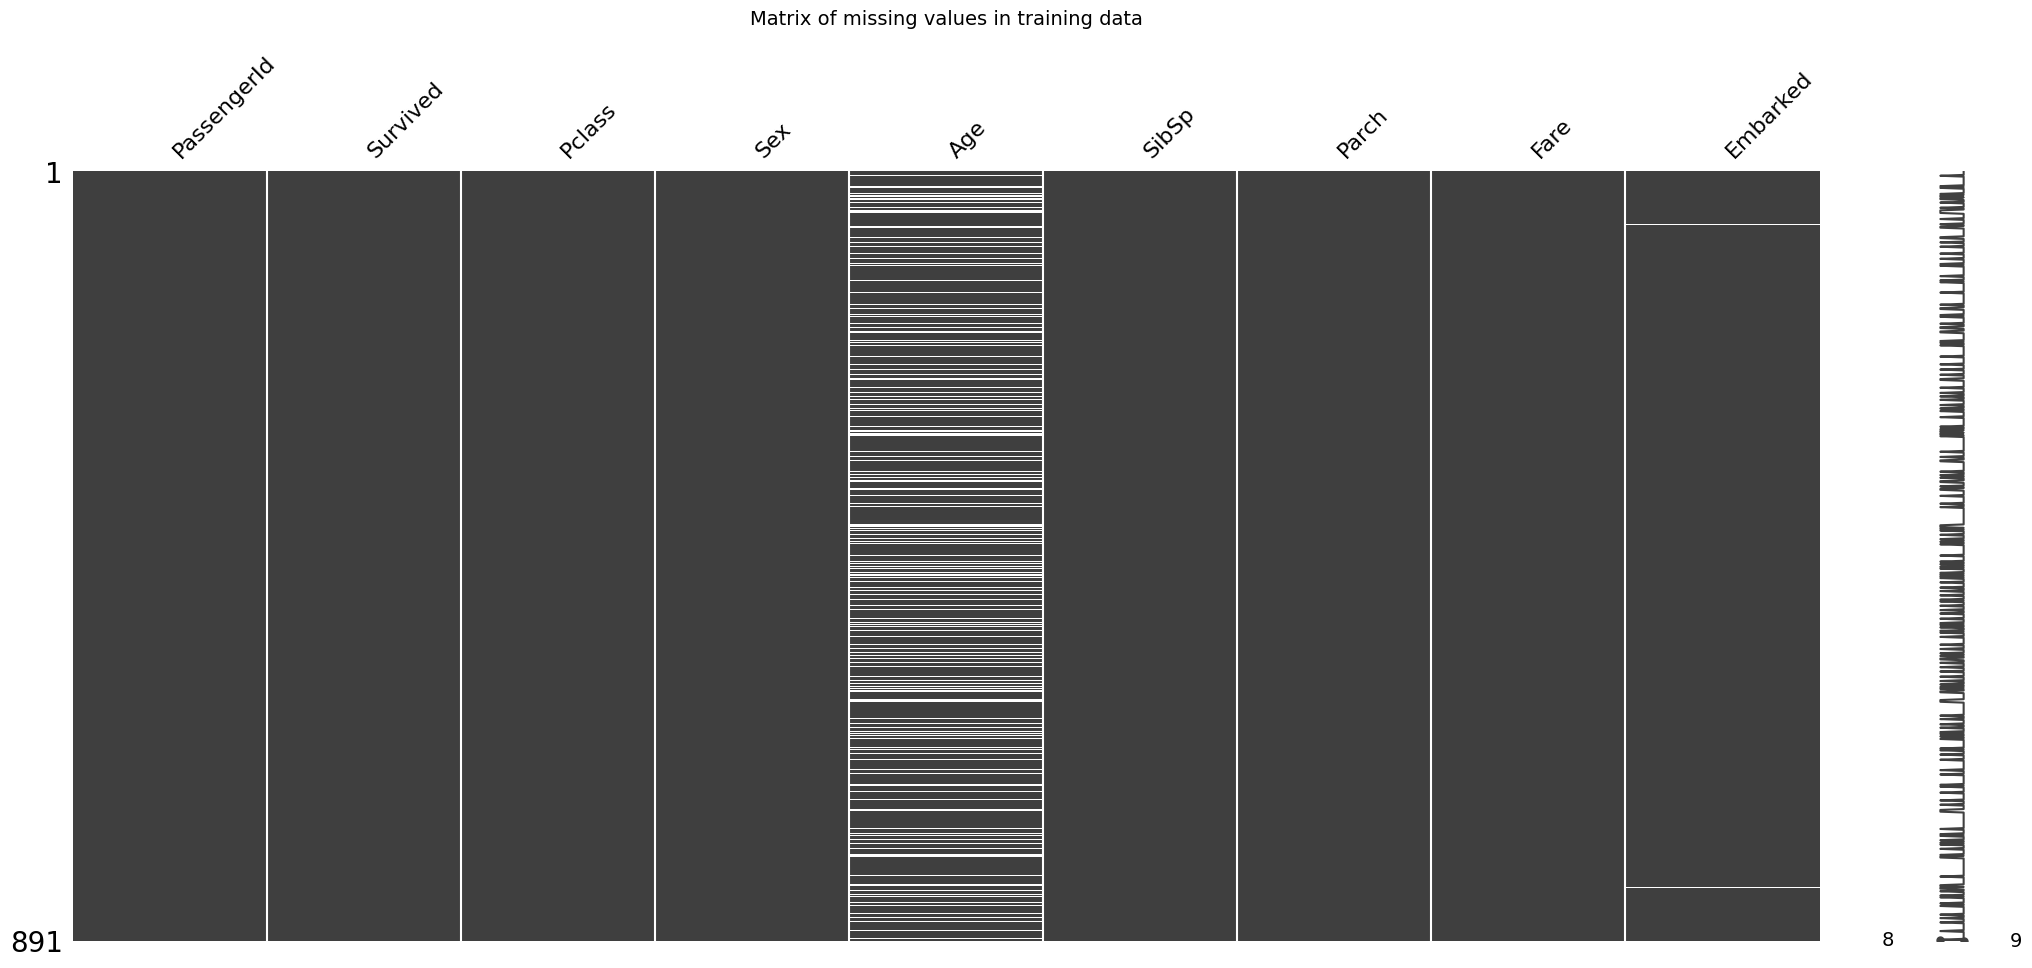

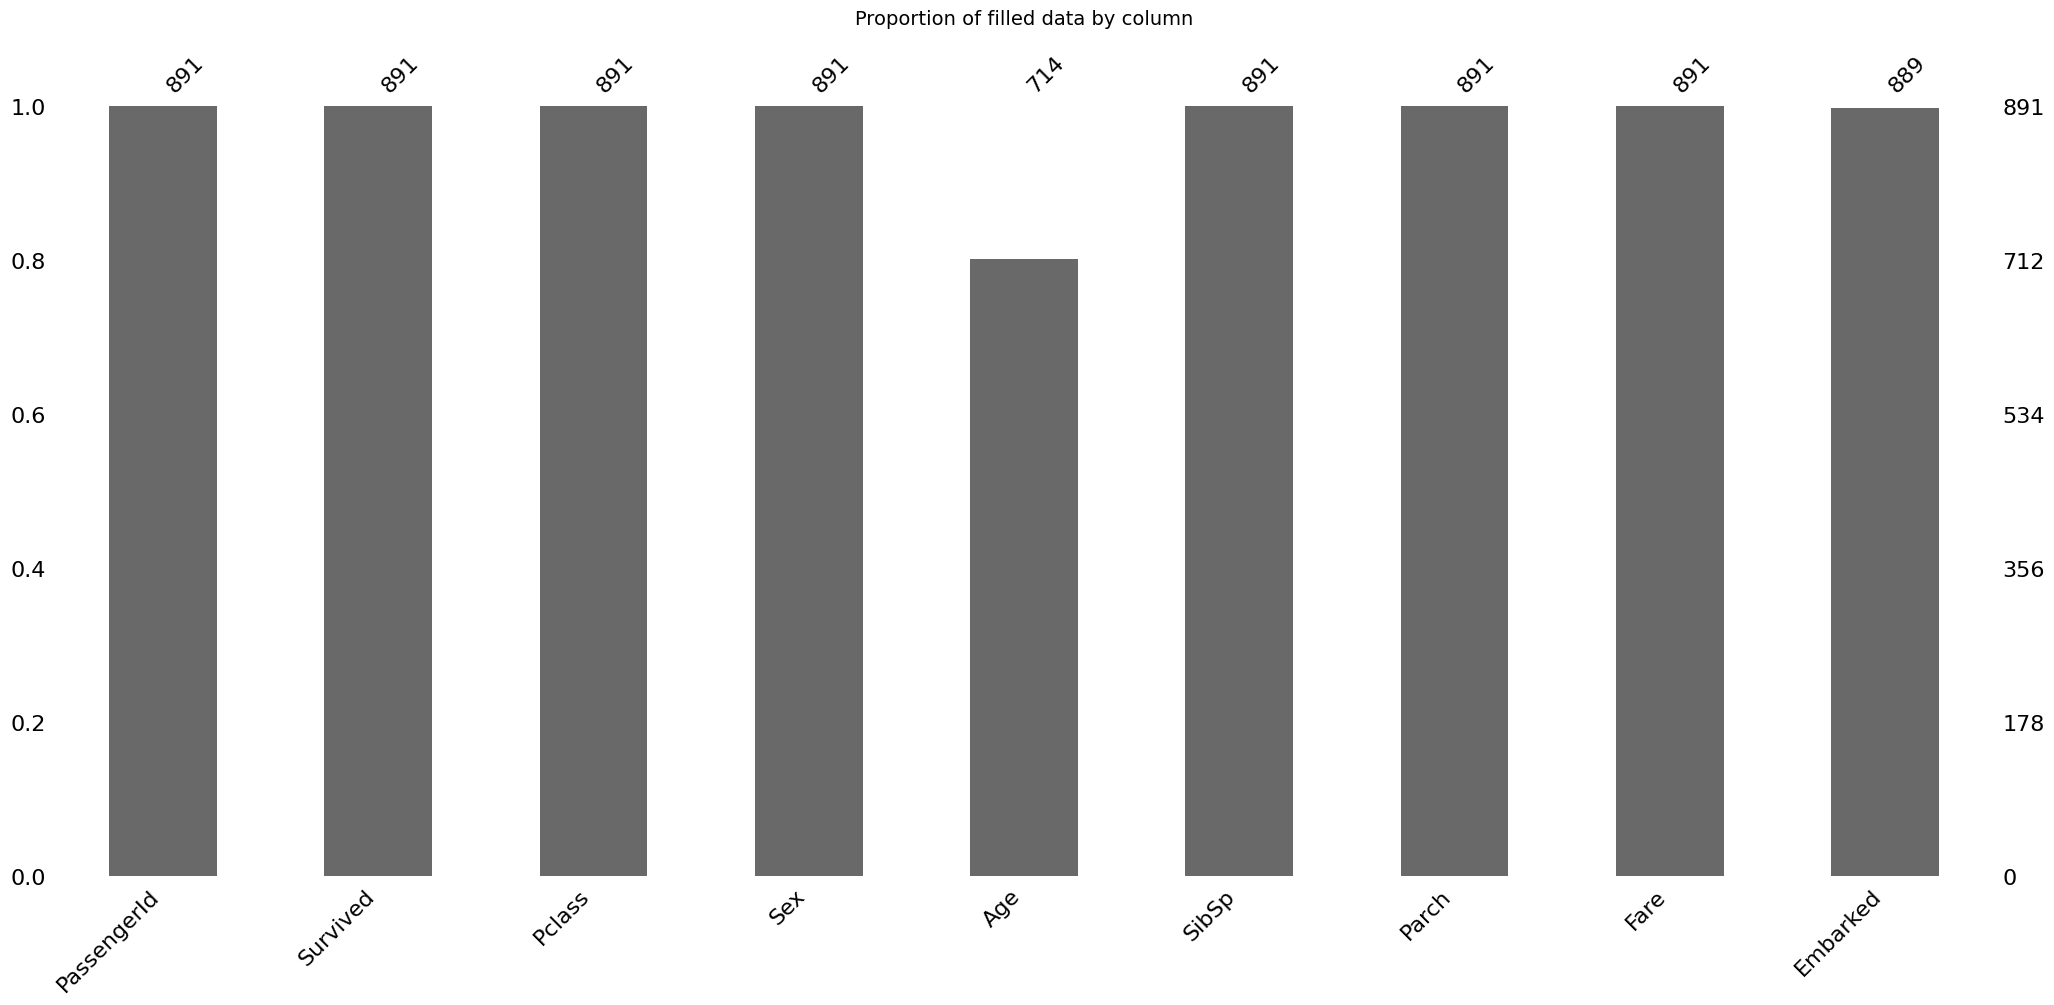

In [425]:
import missingno as msno
# Visualizing missing values ​​in the training set
plt.figure(figsize=(12, 8))
msno.matrix(train)
plt.title('Matrix of missing values ​​in training data', fontsize=14, pad=20)
plt.show()

# You can also plot a bar chart of missing values
plt.figure(figsize=(12, 6))
msno.bar(train)
plt.title('Proportion of filled data by column', fontsize=14, pad=20)
plt.show()

#### 2.2.2 Зависимость пропусков в возрасте от других признаков

Проверим, есть ли связь между наличием пропуска в колонке Age и другими характеристиками пассажиров (пол, класс выживания). Это поможет понять, являются ли пропуски случайными или систематическими.

=== Пропуски возраста по полу ===
        Всего  Пропусков  Доля пропусков
Sex                                     
female    314         53           0.169
male      577        124           0.215

=== Пропуски возраста по классу билета ===
        Всего  Пропусков  Доля пропусков
Pclass                                  
1         216         30           0.139
2         184         11           0.060
3         491        136           0.277

=== Пропуски возраста по выживаемости ===
          Всего  Пропусков  Доля пропусков
Survived                                  
0           549        125           0.228
1           342         52           0.152


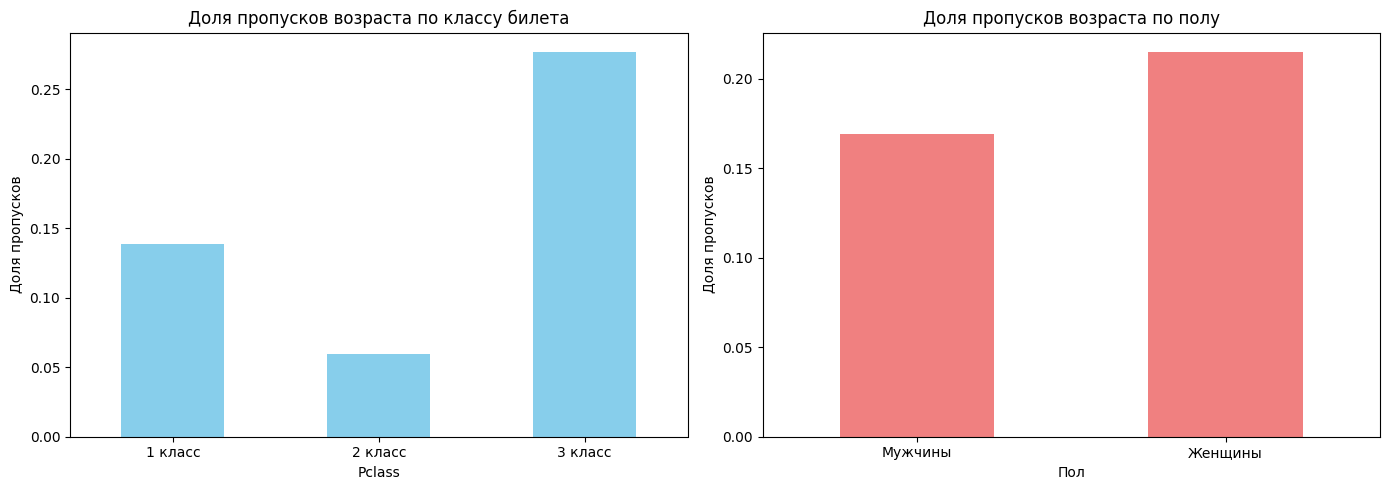

In [426]:
# Создадим вспомогательную колонку-индикатор пропуска возраста
train['Age_missing'] = train['Age'].isnull()

# Анализ по полу
print("=== Пропуски возраста по полу ===")
age_missing_by_sex = train.groupby('Sex')['Age_missing'].agg(['count', 'sum', 'mean'])
age_missing_by_sex.columns = ['Всего', 'Пропусков', 'Доля пропусков']
print(age_missing_by_sex.round(3))
print()

# Анализ по классу билета
print("=== Пропуски возраста по классу билета ===")
age_missing_by_pclass = train.groupby('Pclass')['Age_missing'].agg(['count', 'sum', 'mean'])
age_missing_by_pclass.columns = ['Всего', 'Пропусков', 'Доля пропусков']
print(age_missing_by_pclass.round(3))
print()

# Анализ по выживаемости
print("=== Пропуски возраста по выживаемости ===")
age_missing_by_survived = train.groupby('Survived')['Age_missing'].agg(['count', 'sum', 'mean'])
age_missing_by_survived.columns = ['Всего', 'Пропусков', 'Доля пропусков']
print(age_missing_by_survived.round(3))

# Визуализация зависимости пропусков от класса и пола
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# По классу билета
age_missing_by_pclass['Доля пропусков'].plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Доля пропусков возраста по классу билета')
axes[0].set_xlabel('Pclass')
axes[0].set_ylabel('Доля пропусков')
axes[0].set_xticklabels(['1 класс', '2 класс', '3 класс'], rotation=0)

# По полу
age_missing_by_sex['Доля пропусков'].plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title('Доля пропусков возраста по полу')
axes[1].set_xlabel('Пол')
axes[1].set_ylabel('Доля пропусков')
axes[1].set_xticklabels(['Мужчины', 'Женщины'], rotation=0)

plt.tight_layout()
plt.show()

# Удалим вспомогательную колонку, чтобы не мешала дальнейшему анализу
train.drop('Age_missing', axis=1, inplace=True)

#### 2.2.3 Сравнение распределений для понимания механизма пропусков

Сравним распределения признаков, по которым у нас есть пропуски, с распределениями тех же признаков в полных данных. Это поможет оценить, насколько сильно заполнение повлияет на общую картину

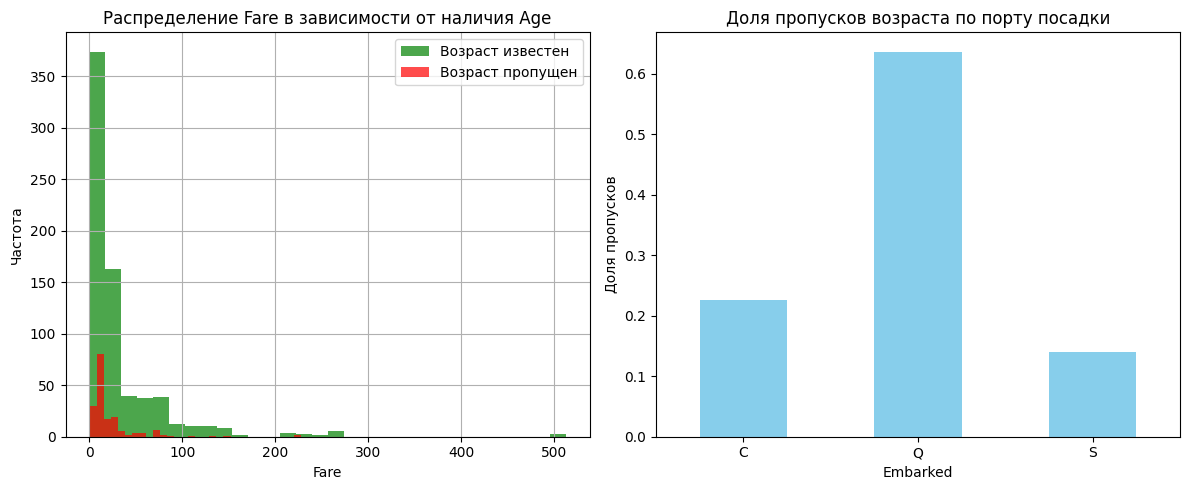


=== Анализ единственного пропуска в Fare (тестовые данные) ===
Пассажир с пропущенной стоимостью билета:
     PassengerId  Pclass   Sex   Age Embarked
152         1044       3  male  60.5        S

Медианная стоимость для класса 3 и порта S: 8.05

=== Анализ пропусков в Embarked (тренировочные данные) ===
Пассажиры с пропущенным портом посадки:
     PassengerId  Pclass     Sex  Fare  Survived
61            62       1  female  80.0         1
829          830       1  female  80.0         1


In [427]:
# Создадим копию данных для анализа
train_analysis = train.copy()

# Добавим индикатор пропуска возраста (еще раз, если удалили)
train_analysis['Age_missing'] = train_analysis['Age'].isnull()

# Сравним стоимость билета для пассажиров с известным и неизвестным возрастом
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
train_analysis[~train_analysis['Age_missing']]['Fare'].hist(bins=30, alpha=0.7, label='Возраст известен', color='green')
train_analysis[train_analysis['Age_missing']]['Fare'].hist(bins=30, alpha=0.7, label='Возраст пропущен', color='red')
plt.xlabel('Fare')
plt.ylabel('Частота')
plt.title('Распределение Fare в зависимости от наличия Age')
plt.legend()

# Анализ порта посадки для пассажиров с пропущенным возрастом
plt.subplot(1, 2, 2)
embarked_age_missing = train_analysis.groupby('Embarked')['Age_missing'].mean()
embarked_age_missing.plot(kind='bar', color='skyblue')
plt.title('Доля пропусков возраста по порту посадки')
plt.xlabel('Embarked')
plt.ylabel('Доля пропусков')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# Анализ пропусков в Fare (тестовые данные)
print("\n=== Анализ единственного пропуска в Fare (тестовые данные) ===")
fare_missing = test[test['Fare'].isnull()]
if not fare_missing.empty:
    print("Пассажир с пропущенной стоимостью билета:")
    print(fare_missing[['PassengerId', 'Pclass', 'Sex', 'Age', 'Embarked']])
    
    # Посмотрим медианную стоимость для похожих пассажиров
    similar_passengers = test[(test['Pclass'] == fare_missing['Pclass'].iloc[0]) & 
                              (test['Embarked'] == fare_missing['Embarked'].iloc[0])]
    print(f"\nМедианная стоимость для класса {fare_missing['Pclass'].iloc[0]} и порта {fare_missing['Embarked'].iloc[0]}: {similar_passengers['Fare'].median():.2f}")

# Анализ пропусков в Embarked (тренировочные данные)
print("\n=== Анализ пропусков в Embarked (тренировочные данные) ===")
embarked_missing = train[train['Embarked'].isnull()]
if not embarked_missing.empty:
    print("Пассажиры с пропущенным портом посадки:")
    print(embarked_missing[['PassengerId', 'Pclass', 'Sex', 'Fare', 'Survived']])

#### 2.2.4 Стратегия обработки пропусков на основе анализа

На основе проведенного анализа можно сделать следующие выводы:

1. **Age**: Пропуски в возрасте распределены неравномерно. 
   - Мужчины пропускали возраст чаще, чем женщины.
   - Пассажиры 3-го класса имеют наибольшую долю пропусков возраста.
   - Это говорит о том, что простого заполнения средним/медианным по всей выборке может быть недостаточно. Более корректным будет заполнение медианным значением внутри групп (по классу и полу).

2. **Cabin**: Более 75% пропусков. Колонку лучше удалить, так как любое заполнение внесет слишком много шума.

3. **Embarked**: Всего 2 пропуска. Можно безопасно заполнить самым частым значением (модой).

4. **Fare**: 1 пропуск в тестовых данных. Логично заполнить медианной стоимостью для аналогичного класса и порта посадки.

### 5. Очистка и подготовка признаков

#### 5.1 Удаление неинформативных колонок
- `Ticket` — слишком много уникальных значений, сложно извлечь полезную информацию без глубокого анализа.
- `Cabin` — слишком много пропусков (>75%).
- `Name` — хотя имя может содержать титулы (Mr, Mrs и т.д.), в данной работе мы не проводим извлечение признаков из имени, поэтому удаляем.

#### 5.2 Выделение матрицы признаков и целевой переменной
Для обучения берём колонки: `Age`, `Pclass`, `SibSp`, `Parch`, `Fare`, `Sex`, `Embarked`. Целевая переменная — `Survived`.

#### 5.3 Заполнение пропусков
- `Age` — заполняем медианным значением (28.0), чтобы не искажать распределение выбросами.
- `Embarked` — заменяем на самое частое значение (моду), порт Southampton.
- `Fare` в тестовом наборе — тоже заполним позже, но в тренировочном пропусков в `Fare` нет.

#### 5.4 Кодирование категориальных признаков
- `Sex` преобразуем в числовой: male → 0, female → 1.
- `Embarked` кодируем: C → 0, Q → 1, S → 2.

#### 5.5 Разделение на обучающую и валидационную выборки
Используем `train_test_split` с параметрами: test_size=0.3, random_state=7 для воспроизводимости.

In [ ]:
test.describe(include="all")

,PassengerId,Pclass,Name,Sex,Age,...,Parch,Ticket,Fare,Cabin,Embarked
count,418.000000,418.000000,418,418,332.000000,...,418.000000,418,417.000000,91,418
unique,NaN,NaN,418,2,NaN,...,NaN,363,NaN,76,3
top,NaN,NaN,"Kelly, Mr. James",male,NaN,...,NaN,PC 17608,NaN,B57 B59 B63 B66,S
freq,NaN,NaN,1,266,NaN,...,NaN,5,NaN,3,270
mean,1100.500000,2.265550,NaN,NaN,30.272590,...,0.392344,NaN,35.627188,NaN,NaN
std,120.810458,0.841838,NaN,NaN,14.181209,...,0.981429,NaN,55.907576,NaN,NaN
min,892.000000,1.000000,NaN,NaN,0.170000,...,0.000000,NaN,0.000000,NaN,NaN
25%,996.250000,1.000000,NaN,NaN,21.000000,...,0.000000,NaN,7.895800,NaN,NaN
50%,1100.500000,3.000000,NaN,NaN,27.000000,...,0.000000,NaN,14.454200,NaN,NaN
75%,1204.750000,3.000000,NaN,NaN,39.000000,...,0.000000,NaN,31.500000,NaN,NaN


In [394]:
#Droping Useless Columns
train = train.drop(['Ticket'], axis = 1)
test = test.drop(['Ticket'], axis = 1)

In [395]:
train = train.drop(['Cabin'], axis = 1)
test = test.drop(['Cabin'], axis = 1)

In [396]:
train = train.drop(['Name'], axis = 1)
test = test.drop(['Name'], axis = 1)

In [397]:
#Feature Selection
column_train=['Age','Pclass','SibSp','Parch','Fare','Sex','Embarked']
#training values
X=train[column_train]
#target value
Y=train['Survived']

In [430]:

# Сохраним исходные данные для анализа
X_raw = X.copy()

# Заполнение Age с учетом группы (Pclass и Sex)
print("Заполнение пропусков Age медианными значениями по группам (Pclass, Sex)...")

# Вычислим медианный возраст для каждой комбинации класса и пола
age_medians = X_raw.groupby(['Pclass', 'Sex'])['Age'].median()
print("\nМедианный возраст по группам:")
print(age_medians)

# Функция для заполнения пропусков
def fill_age(row):
    if pd.isnull(row['Age']):
        return age_medians[row['Pclass'], row['Sex']]
    else:
        return row['Age']

# Применяем функцию
X['Age'] = X_raw.apply(fill_age, axis=1)

# Проверяем, что пропусков больше нет
print(f"\nОсталось пропусков в Age: {X['Age'].isnull().sum()}")

# Заполнение Embarked модой
mode_embarked = train['Embarked'].mode()[0]
X['Embarked'] = train['Embarked'].fillna(mode_embarked)

# Заполнение Fare в тестовых данных (если потребуется позже)
# test['Fare'] = test['Fare'].fillna(test.groupby(['Pclass', 'Embarked'])['Fare'].transform('median'))

print("Пропуски успешно обработаны.")

Заполнение пропусков Age медианными значениями по группам (Pclass, Sex)...

Медианный возраст по группам:
Pclass  Sex
1       0      36.0
        1      32.5
2       0      29.0
        1      28.0
3       0      28.0
        1      28.0
Name: Age, dtype: float64

Осталось пропусков в Age: 0
Пропуски успешно обработаны.


In [401]:
#now we need to convert sex into integer value 
d={'male':0, 'female':1}
X['Sex']=X['Sex'].apply(lambda x:d[x])
X['Sex'].head()

0    0
1    1
2    1
3    1
4    0
Name: Sex, dtype: int64

In [402]:
e={'C':0, 'Q':1 ,'S':2}
X['Embarked']=X['Embarked'].apply(lambda x:e[x])
X['Embarked'].head()

0    2
1    0
2    2
3    2
4    2
Name: Embarked, dtype: int64

In [417]:
#Training Testing and Spliting the model
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X,Y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

### 6. Построение моделей классификации

Для решения задачи применяются несколько алгоритмов. Оценка производится по точности (accuracy) на валидационной выборке.

#### 6.1 Логистическая регрессия
Простая линейная модель для бинарной классификации.  
**Accuracy:** 0.757

#### 6.2 Метод опорных векторов (SVC)
Используется ядро RBF (по умолчанию).  
**Accuracy:** 0.660

#### 6.3 K ближайших соседей (KNN)
Количество соседей = 5.  
**Accuracy:** 0.657

#### 6.4 Наивный байесовский классификатор (GaussianNB)
Предполагает нормальное распределение признаков.  
**Accuracy:** 0.769

#### 6.5 Дерево решений
Критерий разделения — энтропия, random_state=7.  
**Accuracy:** 0.743

#### 6.6 Сравнение моделей
Составлена сводная таблица точности. Лучший результат показал наивный байесовский классификатор (0.77), затем логистическая регрессия (0.75) и дерево решений (0.74). SVC и KNN показали худшие результаты (0.66).

Дополнительно для каждой модели выведены матрица ошибок и отчёт о классификации, чтобы оценить precision, recall и f1-score.

In [ ]:
#Using LogisticRegression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,Y_train)
Y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(Y_test,Y_pred))

Accuracy Score: 0.7574626865671642


In [405]:
#Confusion Matrix
from sklearn.metrics import accuracy_score,confusion_matrix
confusion_mat = confusion_matrix(Y_test,Y_pred)
print(confusion_mat)

[[130  26]
 [ 39  73]]


In [406]:
#Using Support Vector
from sklearn.svm import SVC
model1 = SVC()
model1.fit(X_train,Y_train)

pred_y = model1.predict(X_test)

from sklearn.metrics import accuracy_score
print("Acc=",accuracy_score(Y_test,pred_y))

Acc= 0.6604477611940298


In [407]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
confusion_mat = confusion_matrix(Y_test,pred_y)
print(confusion_mat)
print(classification_report(Y_test,pred_y))

[[149   7]
 [ 84  28]]
              precision    recall  f1-score   support

           0       0.64      0.96      0.77       156
           1       0.80      0.25      0.38       112

    accuracy                           0.66       268
   macro avg       0.72      0.60      0.57       268
weighted avg       0.71      0.66      0.61       268



In [418]:
#Using KNN Neighbors
from sklearn.neighbors import KNeighborsClassifier
model2 = KNeighborsClassifier(n_neighbors=KNN_N_NEIGHBORS)
model2.fit(X_train,Y_train)
y_pred2 = model2.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(Y_test,y_pred2))

Accuracy Score: 0.6567164179104478


In [409]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
confusion_mat = confusion_matrix(Y_test,y_pred2)
print(confusion_mat)
print(classification_report(Y_test,y_pred2))

[[126  30]
 [ 62  50]]
              precision    recall  f1-score   support

           0       0.67      0.81      0.73       156
           1       0.62      0.45      0.52       112

    accuracy                           0.66       268
   macro avg       0.65      0.63      0.63       268
weighted avg       0.65      0.66      0.64       268



In [410]:
#Using GaussianNB
from sklearn.naive_bayes import GaussianNB
model3 = GaussianNB()
model3.fit(X_train,Y_train)
y_pred3 = model3.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(Y_test,y_pred3))

Accuracy Score: 0.7686567164179104


In [411]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
confusion_mat = confusion_matrix(Y_test,y_pred3)
print(confusion_mat)
print(classification_report(Y_test,y_pred3))

[[129  27]
 [ 35  77]]
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       156
           1       0.74      0.69      0.71       112

    accuracy                           0.77       268
   macro avg       0.76      0.76      0.76       268
weighted avg       0.77      0.77      0.77       268



In [419]:
#Using Decision Tree
from sklearn.tree import DecisionTreeClassifier
model4 = DecisionTreeClassifier(
    criterion=DT_CRITERION,
    random_state=RANDOM_STATE
)
model4.fit(X_train,Y_train)
y_pred4 = model4.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(Y_test,y_pred4))

Accuracy Score: 0.7425373134328358


In [413]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
confusion_mat = confusion_matrix(Y_test,y_pred4)
print(confusion_mat)
print(classification_report(Y_test,y_pred4))

[[132  24]
 [ 45  67]]
              precision    recall  f1-score   support

           0       0.75      0.85      0.79       156
           1       0.74      0.60      0.66       112

    accuracy                           0.74       268
   macro avg       0.74      0.72      0.73       268
weighted avg       0.74      0.74      0.74       268



In [414]:
results = pd.DataFrame({
    'Model': ['Logistic Regression','Support Vector Machines', 'Naive Bayes','KNN' ,'Decision Tree'],
    'Score': [0.75,0.66,0.76,0.66,0.74]})

result_df = results.sort_values(by='Score', ascending=False)
result_df = result_df.set_index('Score')
result_df.head(9)

,Model
Score,
0.76,Naive Bayes
0.75,Logistic Regression
0.74,Decision Tree
0.66,Support Vector Machines
0.66,KNN


## 7. Выводы

- Наиболее значимыми признаками оказались `Sex`, `Pclass` и `Fare`.
- Наивный байесовский классификатор показал наилучшую точность (около 77%), что объясняется хорошей разделимостью классов по этим признакам.
- Модели можно улучшить с помощью настройки гиперпараметров, создания новых признаков (например, выделение титулов из имени, группировка возраста), а также балансировки классов.
- Полученная модель может быть использована для предсказания выживаемости на тестовых данных (файл test.csv) после аналогичной предобработки.